In [1]:
import subprocess
import sys
import re
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np
import spacehub_calc
import matplotlib.animation as animation


In [ ]:
title = "TwoBodyPN2p5"

cppFile = f"simulations/{title}.cpp"
execFile = cppFile[:-4]
makecmd = f"g++ -std=c++17 -O3 -pthread {cppFile} -o {execFile}"
simresultFile = f"simulation_results/PN2p5/150-150-0.6-0.05.txt"

Init conditions:

$a_0 = 0.05 AU, \ e = 0.6, \ M_1 = M_2 = 130 M_{\odot}$

In [3]:

#clean
result = subprocess.run(
f"rm {execFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)

result = subprocess.run(
f"rm simulation_results/Result.txt", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)

result = subprocess.run(
f"rm {simresultFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    
print("Cleaned")

#make
result = subprocess.run(
makecmd, 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise OSError("Make error")
print("Made")

#run sim
result = subprocess.run(
f"./{execFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=30000
)
if result.returncode != 0:
    print(result.stdout)
    raise OSError("Runtime error")
print("Executed with exit code 0")
print(result.stdout)




rm: cannot remove 'simulations/TwoBodyPN2p5': No such file or directory


rm: cannot remove 'simulation_results/Result.txt': No such file or directory


rm: cannot remove 'simulation_results/PN2p5/150-150-0.6-0.05.txt': No such file or directory

Cleaned
Made


KeyboardInterrupt: 

In [4]:
#Rename output file
result = subprocess.run(
f"mv simulation_results/Result.txt {simresultFile}", 
shell=True, 
capture_output=True, 
text=True,
timeout=300
)
if result.returncode != 0:
    print(result.stdout)
    print("WARNING! Could not move rename Result.txt")
print("Executed with exit code 0")
print(result.stdout)

Executed with exit code 0



In [ ]:
simpleOrbit = spacehub_calc.TwoBodyOrbit(simresultFile, 0, 1)

In [ ]:
print(simpleOrbit)

Initial (t=0) Conditions:
a: 0.09999999999999769AU
e: 0.9499999999999988
i: 1.0000000000002647deg
Longtiude of Ascending Node: 0.9999999999997357deg
Argument of Periapsis: 0.9999999999991713deg
True Anomaly: 360.0deg
Orbital Separation: 0.005000000000000003



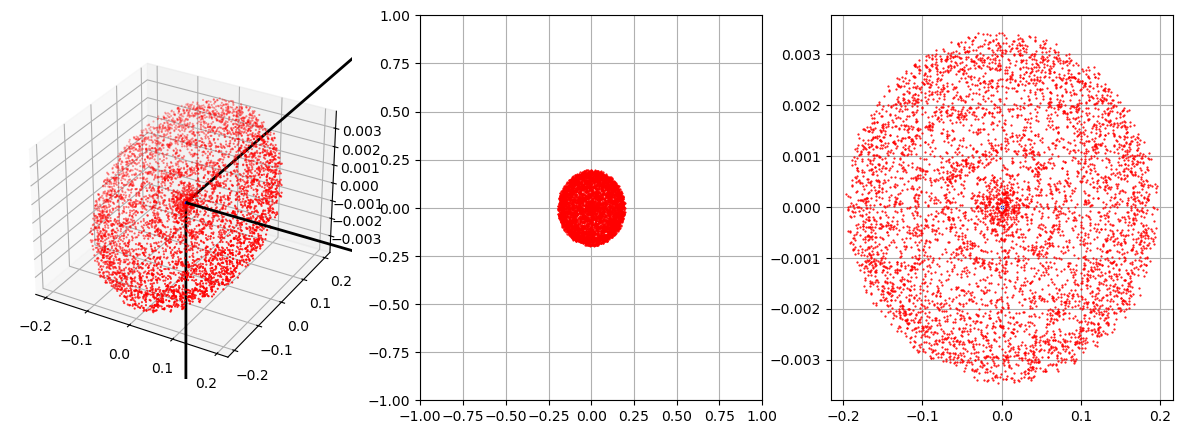

In [ ]:
fig, axes = simpleOrbit.plot_orbit_3panel()

(<Figure size 1500x1000 with 6 Axes>,
 array([<Axes: title={'center': 'Eccentricity'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$e$'>,
        <Axes: title={'center': 'Inclination'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$i$ (deg)'>,
        <Axes: title={'center': 'Separation'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$||R||$ ($AU$)'>,
        <Axes: title={'center': 'Longitude of Ascending Node'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$\\Omega$ (deg)'>,
        <Axes: title={'center': 'Semi-major Axis'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$a$ (AU)'>,
        <Axes: title={'center': 'Argument of Periapsis'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$\\omega$ (deg)'>],
       dtype=object))

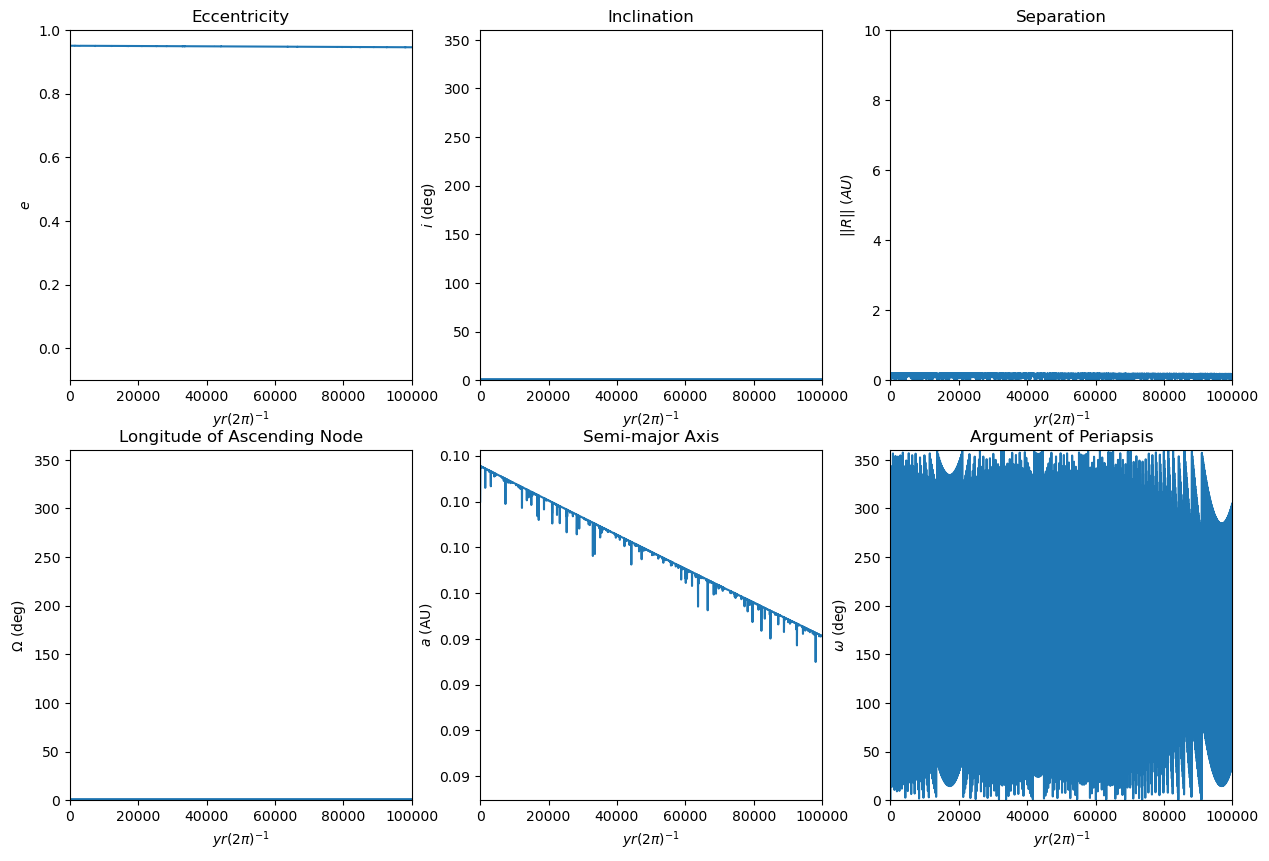

In [ ]:
simpleOrbit.plot_keplerian_evolution_basic(xlim=[0,100000])


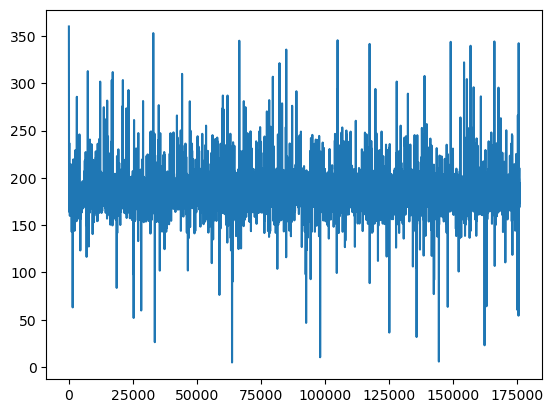

In [ ]:
plt.plot(simpleOrbit.time, simpleOrbit.true_anomaly_deg)

In [ ]:
simpleOrbit.data

,time,id,mass,px,py,pz,vx,vy,vz,p,v
0,0.000000,0.0,30.0,0.002498,0.000087,7.614662e-07,-2.669095,76.427054,1.334649,0.002500,76.485293
1,0.000000,1.0,30.0,-0.002498,-0.000087,-7.614662e-07,2.669095,-76.427054,-1.334649,0.002500,76.485293
2,31.416992,0.0,30.0,0.000288,-0.046463,-8.109873e-04,1.743324,14.078978,0.245181,0.046471,14.188619
3,31.416992,1.0,30.0,-0.016423,0.037975,6.677521e-04,-1.744177,-14.079719,-0.245194,0.041379,14.189459
4,62.831873,0.0,30.0,0.050309,-0.037009,-6.612155e-04,-7.059214,4.017927,0.072273,0.062458,8.122898
...,...,...,...,...,...,...,...,...,...,...,...
11207,176023.438152,1.0,30.0,2.740302,-78.989924,-1.379399e+00,2.171177,-4.601767,-0.080973,79.049479,5.088892
11208,176054.853035,0.0,30.0,2.690786,-78.946626,-1.378628e+00,6.504939,-0.245604,-0.006268,79.004498,6.509577
11209,176054.853035,1.0,30.0,2.818087,-78.892859,-1.377729e+00,-6.505119,0.245573,0.006268,78.955196,6.509756
11210,176086.268816,0.0,30.0,2.769309,-79.000595,-1.379594e+00,3.660229,-2.873528,-0.051265,79.061156,4.653715


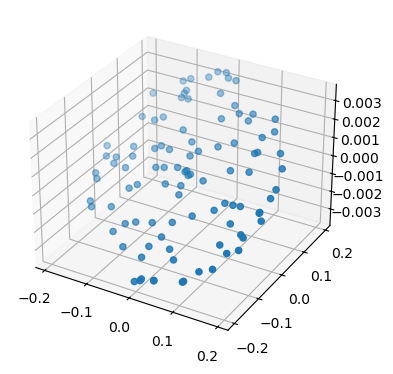

In [ ]:
fig = plt.figure(figsize=(15, 5))
ax0 = fig.add_subplot(131, projection='3d')

ax0.scatter(simpleOrbit.R_vec[0][0:100], simpleOrbit.R_vec[1][0:100], simpleOrbit.R_vec[2][0:100])